In [1]:
import io
import matplotlib.pyplot as plt
import os
import base64
from PIL import Image
import json
from inference_sdk import InferenceHTTPClient

C:\Users\laura\anaconda3\envs\cv\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## Input images and output folder

In [2]:
image_folder = "./images/isolated_trees/"
image_file_names = ["tree1.jpg", "tree2.jpg"]
output_folder = "./outputs/tree_angles/"

## Load Roboflow API key

In [3]:
with open("./roboflow_api_key.json", "r") as f:
    ROBOFLOW_API_KEY = json.load(f)["API_KEY"]

print(ROBOFLOW_API_KEY)

JHdm1Ivm2PmTD5VViuVN


## Run the workflow

In [4]:
client = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key=ROBOFLOW_API_KEY
)

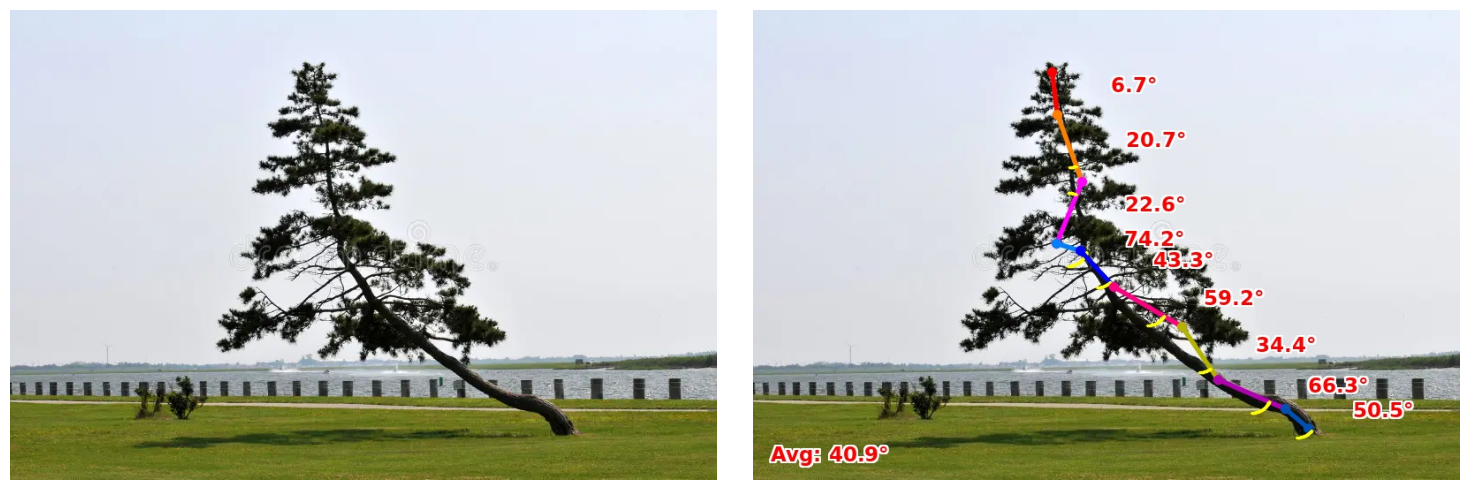

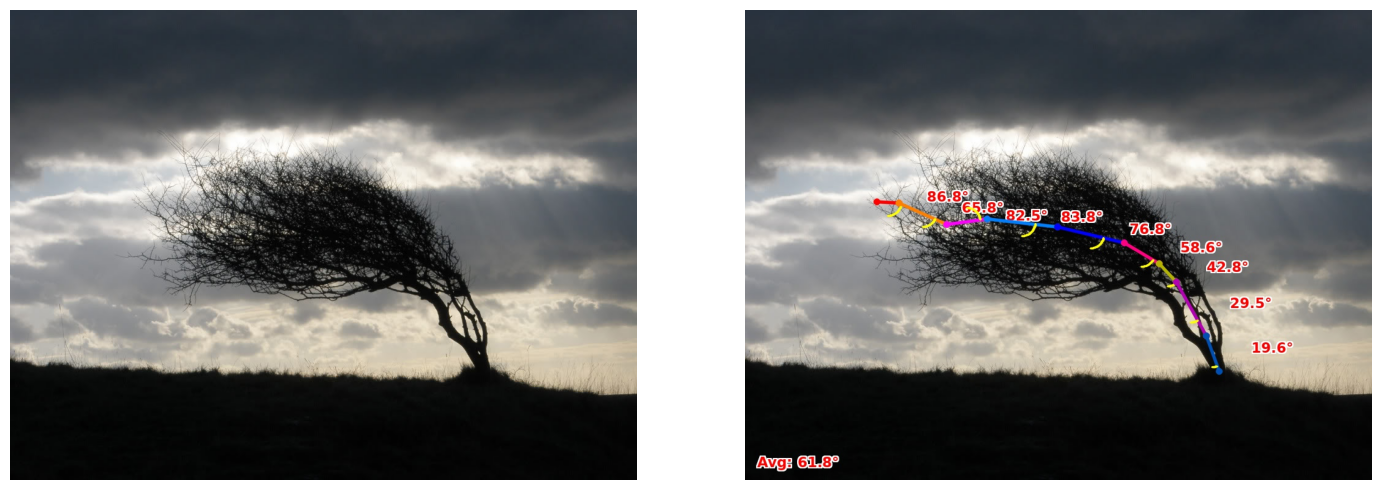

In [5]:
for file_name in image_file_names:
    image_path = image_folder + file_name

    #run the workflow
    result = client.run_workflow(
        workspace_name = "domen-k",
        workflow_id = "tree-trunk-angle-offset",
        images={
            "image": image_path
        }
    )

    #plot the input and output images
    image_bytes = base64.b64decode(result[0]['output_image'])
    img = Image.open(io.BytesIO(image_bytes))
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].imshow(Image.open(image_path))
    axes[1].imshow(img)
    axes[0].axis('off')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    #save output to disk
    os.makedirs(output_folder, exist_ok=True)
    img.save(output_folder + file_name)